# 🔍 Stage 1 — Baseline Anomaly Detector on MVTec AD

**Project:** Energy-Aware Visual Anomaly Detection on MCUs  
**Stage:** 1 / 4 — train an FP32 baseline that fits the MCU budget *before* any compression.

## What this notebook does

1. Sets up the environment (PyTorch + utilities).
2. Downloads MVTec AD (one or two categories) into Colab.
3. Defines a **compact convolutional autoencoder** sized to fit a Cortex-M4 (Arduino Nano 33 BLE Sense Rev 2 — 256 KB SRAM, 1 MB Flash).
4. Trains it on **defect-free images only** (unsupervised).
5. Evaluates on the MVTec test set: per-image AUROC, qualitative reconstructions, score histograms.
6. Reports parameter count, MAC count, and estimated INT8 model size to confirm we are in MCU-budget territory.
7. Saves the model in a format ready for Stage 2 (compression).

## Why an autoencoder and not PaDiM / PatchCore / EfficientAD?

PaDiM / PatchCore rely on a **pretrained ImageNet backbone** (Wide-ResNet, EfficientNet) and a large memory bank or covariance matrices — neither of which fits a 256 KB SRAM MCU after compression. They are great references for AUROC on a workstation, but they are not realistic Stage-1 baselines for our deployment target.

A small CNN autoencoder trained from scratch on defect-free images is:

- small enough to fit a Cortex-M4 after INT8 quantization;
- well-suited to all three of our Stage-2 compression techniques (PTQ, structured pruning, distillation);
- a fair representative of what gets deployed in published MCU-class anomaly detection work.

We may revisit a feature-based head later, but we will not get one to fit on the MCU without making it look like an autoencoder anyway.

## Why PyTorch, not TensorFlow

Stage 2 needs structured filter pruning with Taylor-importance ranking. PyTorch's tooling for this is more mature than TFMOT's. The TFLite export path used by Stage 3 starts from PyTorch via ONNX. We accept the conversion cost (one script) in exchange for a smoother compression workflow.

---

## 0. Environment setup

Colab already provides PyTorch and CUDA. We install only the few extras we actually need.

- `scikit-learn` — for AUROC.
- `ptflops` — measures MACs / parameters of a PyTorch model.
- `tqdm`, `matplotlib`, `Pillow` — UI + plotting.

We pin nothing aggressively — Colab's preinstalled versions are fine for Stage 1.

In [1]:
!pip install -q ptflops scikit-learn tqdm matplotlib pillow

In [2]:
import os, random, math, time, json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from ptflops import get_model_complexity_info
from tqdm.auto import tqdm

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Torch:', torch.__version__, '| Device:', DEVICE)

Torch: 2.11.0+cu128 | Device: cuda


In [3]:
import torch
print('CUDA dispo:', torch.cuda.is_available())
print('Device   :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA dispo: True
Device   : Tesla T4


## 1. Configuration & Get the data

All knobs in one place. Defaults are tuned for: one MVTec category, small input resolution (so the AE fits the MCU), short training run that is enough to validate the pipeline. We will sweep categories and epochs later.

MVTec AD is distributed by MVTec Software GmbH under a non-commercial research license. The full dataset is ~4.9 GB. For Stage 1 we only need one category, so we download it from the MVTec mirror.

> ⚠️ If the direct URL changes, download manually from https://www.mvtec.com/company/research/datasets/mvtec-ad and upload the extracted folder to `/content/mvtec/<category>/`.

Expected structure after extraction:

```
/content/mvtec/bottle/
├── train/good/                  # only defect-free images
├── test/
│   ├── good/                    # defect-free test
│   ├── broken_large/
│   ├── broken_small/
│   └── contamination/
└── ground_truth/                # pixel masks (unused at Stage 1)
```

In [6]:
from google.colab import drive
drive.mount('/content/drive')

CFG = {
    'category': 'bottle',
    'image_size': 128,
    'data_root': '/content/mvtec',
    'batch_size': 32,
    'epochs': 200,
    'lr': 1e-3,
    'weight_decay': 1e-5,
    'base_channels': 32,
    'latent_channels': 32,
    'n_down': 3,
    'use_ssim': True,
    'ssim_weight': 0.5,
    'out_dir': '/content/baseline_out',
}
Path(CFG['out_dir']).mkdir(parents=True, exist_ok=True)

# Symlink Drive
import os, shutil
from pathlib import Path

src = '/content/drive/MyDrive/mvtec'   # plus de '/bottle' au bout
dst = '/content/mvtec'

# Nuke whatever is at dst
if os.path.islink(dst): os.unlink(dst)
elif os.path.isdir(dst): shutil.rmtree(dst)
elif os.path.exists(dst): os.remove(dst)

assert os.path.isdir(src), f'Not found: {src}'
os.symlink(src, dst)
print('Categories available:', sorted(os.listdir(dst)))
# attendu: ['bottle', 'hazelnut', 'metal_nut', ...]
cat_dir = Path(CFG['data_root']) / CFG['category']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Categories available: ['bottle', 'carpet', 'hazelnut']


## 3. Dataset and dataloaders

Training set: `train/good` only — unsupervised AE training on defect-free images.
Test set: all subfolders of `test/`, with binary label `0` for `good` and `1` otherwise.

Preprocessing: resize to `image_size`, center-crop, convert to tensor in `[0, 1]`. We **do not** apply ImageNet normalization because we are not using a pretrained backbone and we want to keep the deployed model's input pipeline trivially reproducible on the MCU.

Light augmentation on the train set (small rotation, horizontal flip) helps generalize without changing the defect-free assumption.

In [ ]:
class MVTecTrain(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(5),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB'))

class MVTecTest(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.items = []
        for sub in sorted(Path(root, 'test').iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')):
                self.items.append((p, label, sub.name))
        self.tf = transforms.Compose([
            transforms.Resize(image_size + 16),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, label, defect = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), label, defect

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, has_labels=False):
        self.has_labels = has_labels
        self.tf = base_ds.tf
        if has_labels:
            print(f'Caching {len(base_ds.items)} test images...')
            self.data = [(Image.open(p).convert('RGB').copy(), l, d)
                         for p, l, d in tqdm(base_ds.items)]
        else:
            print(f'Caching {len(base_ds.paths)} train images...')
            self.data = [Image.open(p).convert('RGB').copy()
                         for p in tqdm(base_ds.paths)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        if self.has_labels:
            img, l, d = self.data[i]
            return self.tf(img), l, d
        return self.tf(self.data[i])

# build + cache
train_ds_raw = MVTecTrain(cat_dir, CFG['image_size'])
test_ds_raw  = MVTecTest(cat_dir, CFG['image_size'])
train_ds = CachedDataset(train_ds_raw, has_labels=False)
test_ds  = CachedDataset(test_ds_raw,  has_labels=True)
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
print(f'train: {len(train_ds)} | test: {len(test_ds)}')

Caching 209 train images...


  0%|          | 0/209 [00:00<?, ?it/s]

Caching 83 test images...


  0%|          | 0/83 [00:00<?, ?it/s]

### Visualize a few training images

Quick sanity check on the data.

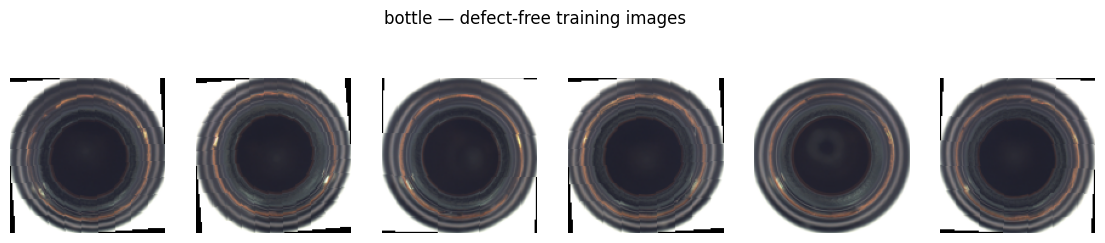

In [33]:
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, i in zip(axes, np.random.choice(len(train_ds), 6, replace=False)):
    img = train_ds[i].permute(1,2,0).numpy()
    ax.imshow(img); ax.axis('off')
plt.suptitle(f'{CFG["category"]} — defect-free training images'); plt.show()

## 4. Model: compact convolutional autoencoder

Architecture summary (128×128 input):

```
Encoder:  3 → C → 2C → 4C → latent          (4 downsamplings, factor 16)
Decoder:  latent → 4C → 2C → C → 3          (mirror, transpose convs)
```

With `C = base_channels = 16` and `latent = 32`, the model lands in the ~80–120 k parameter range — fits a 1 MB Flash budget comfortably after INT8 quantization (≈1 byte/param), and leaves headroom for activations in 256 KB SRAM.

Design choices that matter for Stage 2 / Stage 3:

- **No batch norm** (or only minimal): batch-norm folding works in TFLite but adds friction; using only conv + ReLU keeps quantization clean.
- **ReLU**, not GELU / SiLU: simple activations are quantization-friendly and supported in TFLite Micro.
- **No skip connections** in the baseline. They would hurt reconstruction-error-based anomaly scoring (the model copies the defect through the skip) and complicate pruning. We can revisit.
- **Transpose convs**, not upsample+conv. Either works; transpose convs are supported by TFLM and keep the parameter count visible.

In [20]:
def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 4, stride, 1, bias=True),
        nn.ReLU(inplace=True),
    )

def deconv_block(in_c, out_c, last=False):
    layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=True)]
    if not last: layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)

class CompactAE(nn.Module):
    def __init__(self, base=32, latent=32, n_down=3):
        super().__init__()
        chans = [3] + [base * (2**i) for i in range(n_down)] + [latent]
        self.enc = nn.Sequential(*[
            conv_block(chans[i], chans[i+1]) for i in range(len(chans)-1)
        ])
        rev = list(reversed(chans))
        self.dec = nn.Sequential(*[
            deconv_block(rev[i], rev[i+1], last=(i == len(rev)-2))
            for i in range(len(rev)-1)
        ], nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

model = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Params: {n_params:,} | FP32: {n_params*4/1024:.0f} KB | INT8 est: {n_params/1024:.0f} KB')

Params: 462,307 | FP32: 1806 KB | INT8 est: 451 KB


### Budget check before we train

If the model already blows the MCU budget at FP32, no amount of compression will save it. Sanity-check **before** spending compute.

In [21]:
with torch.cuda.device(0 if DEVICE=='cuda' else -1):
    macs, params = get_model_complexity_info(
        model, (3, CFG['image_size'], CFG['image_size']),
        as_strings=False, print_per_layer_stat=False, verbose=False,
    )

n_params = sum(p.numel() for p in model.parameters())
fp32_kb  = n_params * 4 / 1024
int8_kb  = n_params * 1 / 1024     # approximate (excludes per-tensor scales)

print(f'Parameters : {n_params:,}')
print(f'MACs       : {macs/1e6:.2f} M')
print(f'Size FP32  : {fp32_kb:.1f} KB')
print(f'Size INT8  : {int8_kb:.1f} KB   (target Flash budget: 1024 KB)')

assert int8_kb < 800, 'Model too big for MCU budget after INT8. Shrink base_channels / latent.'

Parameters : 462,307
MACs       : 156.62 M
Size FP32  : 1805.9 KB
Size INT8  : 451.5 KB   (target Flash budget: 1024 KB)


In [22]:
!pip install -q pytorch-msssim
from pytorch_msssim import ssim

mse = nn.MSELoss()
def recon_loss(x_hat, x):
    if CFG['use_ssim']:
        s = 1 - ssim(x_hat, x, data_range=1.0, size_average=True)
        return (1 - CFG['ssim_weight']) * mse(x_hat, x) + CFG['ssim_weight'] * s
    return mse(x_hat, x)

## 5. Training

Loss: pixel-wise **L2** between input and reconstruction. Plain MSE is robust and quantization-friendly; SSIM-based losses are common in the AD literature but harder to deploy on the MCU and not necessary for the baseline.

Optimizer: Adam with `lr=1e-3`, cosine schedule. No early stopping — we let it run the full budget so the loss curve is informative for Stage 2 ablations.

We track the *reconstruction loss on training data* (no validation set on defect-free data — the test set lives in `test/`).

epoch   1 | loss = 0.37487
epoch   2 | loss = 0.37338
epoch   3 | loss = 0.37212
epoch  20 | loss = 0.11661
epoch  40 | loss = 0.09260
epoch  60 | loss = 0.07910
epoch  80 | loss = 0.06733
epoch 100 | loss = 0.05987
epoch 120 | loss = 0.05508
epoch 140 | loss = 0.05281
epoch 160 | loss = 0.05145
epoch 180 | loss = 0.05049
epoch 200 | loss = 0.05122


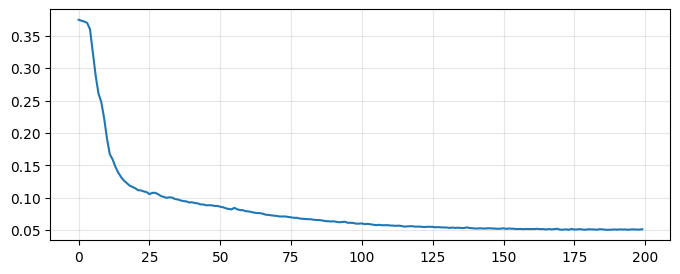

In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

history = []
for epoch in range(CFG['epochs']):
    model.train()
    total, n = 0.0, 0
    for x in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        x_hat = model(x)
        loss = recon_loss(x_hat, x)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * x.size(0); n += x.size(0)
    scheduler.step()
    history.append(total/n)
    if (epoch+1) % 20 == 0 or epoch < 3:
        print(f'epoch {epoch+1:3d} | loss = {history[-1]:.5f}')

plt.figure(figsize=(8,3)); plt.plot(history); plt.grid(alpha=.3); plt.show()

## 6. Evaluation

### Anomaly score

For each test image we compute the per-pixel reconstruction error map `(x - x_hat)^2`, averaged over channels. The image-level anomaly score is the **spatial mean** of that map (alternative: `max` — set in `CFG['score_pool']`).

Reporting:

- **image-level AUROC** — the standard MVTec metric, comparing scores to binary labels.
- a histogram of scores split by `good` vs defect.
- a small grid of reconstructions and error maps.

AUROC is preferred over accuracy because the threshold is application-specific.

In [25]:
@torch.no_grad()
def score_images(model, loader, mode='mean', border=8):
    model.eval()
    scores, labels, defects = [], [], []
    for x, y, d in loader:
        x = x.to(DEVICE)
        x_hat = model(x)
        err = (x - x_hat).pow(2).mean(dim=1)
        if border > 0:
            err = err[:, border:-border, border:-border]
        err = F.avg_pool2d(err.unsqueeze(1), 5, 1, 2).squeeze(1)
        B, H, W = err.shape
        flat = err.view(B, -1)
        if mode == 'max':       s = flat.amax(dim=1)
        elif mode == 'top1pct': s = flat.topk(max(1, H*W//100), dim=1).values.mean(dim=1)
        elif mode == 'top5pct': s = flat.topk(max(1, H*W//20),  dim=1).values.mean(dim=1)
        else:                   s = flat.mean(dim=1)
        scores.append(s.cpu().numpy()); labels.append(y.numpy()); defects.extend(d)
    return np.concatenate(scores), np.concatenate(labels), defects

s, l, d = score_images(model, test_loader, mode='mean', border=8)
print(f'AUROC = {roc_auc_score(l, s):.4f}')

AUROC = 0.9413


In [34]:
def train_one_category(category, epochs=200, seed=42):
    """Entraîne un AE compact sur une catégorie et retourne (model, history, auroc)."""
    print(f'\n{"="*60}\n  TRAINING ON: {category}\n{"="*60}')

    # reproductibilité par catégorie
    torch.manual_seed(seed); np.random.seed(seed)

    # données pour cette catégorie
    cat_dir = Path(CFG['data_root']) / category
    assert cat_dir.exists(), f'Missing category folder: {cat_dir}'
    train_raw = MVTecTrain(cat_dir, CFG['image_size'])
    test_raw  = MVTecTest(cat_dir, CFG['image_size'])
    train_ds  = CachedDataset(train_raw, has_labels=False)
    test_ds   = CachedDataset(test_raw,  has_labels=True)
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                              num_workers=0, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                              num_workers=0, pin_memory=True)

    # modèle vierge (très important : NE PAS réutiliser un model déjà entraîné)
    model = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # training
    history = []
    for epoch in range(epochs):
        model.train()
        total, n = 0.0, 0
        for x in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            x_hat = model(x)
            loss = recon_loss(x_hat, x)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * x.size(0); n += x.size(0)
        scheduler.step()
        history.append(total/n)
        if (epoch+1) % 40 == 0:
            print(f'  epoch {epoch+1:3d} | loss = {history[-1]:.5f}')

    # eval avec le scoring figé
    s, l, d = score_images(model, test_loader, mode='mean', border=8)
    auroc = roc_auc_score(l, s)
    print(f'  → final loss = {history[-1]:.5f} | AUROC = {auroc:.4f}')

    # save checkpoint
    n_params = sum(p.numel() for p in model.parameters())
    ckpt_path = Path(CFG['out_dir']) / f'baseline_{category}.pt'
    torch.save({
        'state_dict': model.state_dict(),
        'config': {**CFG, 'category': category},
        'scoring': {'mode': 'mean', 'border': 8, 'blur_kernel': 5},
        'metrics': {'auroc': float(auroc), 'n_params': n_params},
        'final_train_loss': float(history[-1]),
    }, ckpt_path)
    print(f'  saved: {ckpt_path}')

    return model, history, auroc, (s, l, d)

In [35]:
results = {}
for cat in ['bottle', 'hazelnut', 'metal_nut']:
    model, hist, auroc, scores = train_one_category(cat, epochs=CFG['epochs'])
    results[cat] = {'auroc': auroc, 'final_loss': hist[-1], 'history': hist, 'scores': scores}

# Tableau récap
print('\n' + '='*40)
print(f'{"Category":<15} {"AUROC":>8} {"Final Loss":>12}')
print('-'*40)
for cat, r in results.items():
    print(f'{cat:<15} {r["auroc"]:>8.4f} {r["final_loss"]:>12.5f}')
aurocs = [r['auroc'] for r in results.values()]
print('-'*40)
print(f'{"Mean":<15} {np.mean(aurocs):>8.4f}')


  TRAINING ON: bottle
Caching 209 train images...


  0%|          | 0/209 [00:00<?, ?it/s]

Caching 83 test images...


  0%|          | 0/83 [00:00<?, ?it/s]

  epoch  40 | loss = 0.10403
  epoch  80 | loss = 0.08369
  epoch 120 | loss = 0.06849
  epoch 160 | loss = 0.06368
  epoch 200 | loss = 0.06353
  → final loss = 0.06353 | AUROC = 0.9317
  saved: /content/baseline_out/baseline_bottle.pt

  TRAINING ON: hazelnut
Caching 391 train images...


...

  epoch  40 | loss = 0.06204
  epoch  80 | loss = 0.05192
  epoch 120 | loss = 0.04844
  epoch 160 | loss = 0.04674
  epoch 200 | loss = 0.04640
  → final loss = 0.04640 | AUROC = 0.8361
  saved: /content/baseline_out/baseline_hazelnut.pt

  TRAINING ON: metal_nut
Caching 220 train images...


  0%|          | 0/220 [00:00<?, ?it/s]

Caching 115 test images...


  0%|          | 0/115 [00:00<?, ?it/s]

  epoch  40 | loss = 0.13839
  epoch  80 | loss = 0.10683
  epoch 120 | loss = 0.09639
  epoch 160 | loss = 0.09211
  epoch 200 | loss = 0.09166
  → final loss = 0.09166 | AUROC = 0.4203
  saved: /content/baseline_out/baseline_metal_nut.pt

Category           AUROC   Final Loss
----------------------------------------
bottle            0.9317      0.06353
hazelnut          0.8361      0.04640
metal_nut         0.4203      0.09166
----------------------------------------
Mean              0.7294


In [36]:
ckpt = torch.load('/content/baseline_out/baseline_metal_nut.pt', map_location=DEVICE, weights_only=False)
model_mn = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down']).to(DEVICE)
model_mn.load_state_dict(ckpt['state_dict'])

cat_dir_mn = Path(CFG['data_root']) / 'metal_nut'
test_raw_mn = MVTecTest(cat_dir_mn, CFG['image_size'])
test_ds_mn  = CachedDataset(test_raw_mn, has_labels=True)
test_loader_mn = DataLoader(test_ds_mn, batch_size=32, shuffle=False, num_workers=0)

s, l, d = score_images(model_mn, test_loader_mn, mode='mean', border=8)
from collections import defaultdict
by_d = defaultdict(list)
for sc, df in zip(s, d): by_d[df].append(sc)
print(f'\nAUROC mean+border8 = {roc_auc_score(l, s):.4f}\n')
for df, arr in sorted(by_d.items()):
    arr = np.array(arr)
    print(f'  {df:15s} n={len(arr):3d}  mean={arr.mean():.5f}  median={np.median(arr):.5f}')

Caching 115 test images...


  0%|          | 0/115 [00:00<?, ?it/s]


AUROC mean+border8 = 0.4203

  bent            n= 25  mean=0.00162  median=0.00162
  color           n= 22  mean=0.00171  median=0.00165
  flip            n= 23  mean=0.00189  median=0.00192
  good            n= 22  mean=0.00179  median=0.00177
  scratch         n= 23  mean=0.00154  median=0.00152


In [37]:
for mode in ['mean', 'max', 'top1pct', 'top5pct']:
    s, l, _ = score_images(model_mn, test_loader_mn, mode=mode, border=8)
    print(f'  {mode:10s} border=8 → AUROC = {roc_auc_score(l, s):.4f}')

for border in [0, 4, 8, 16]:
    s, l, _ = score_images(model_mn, test_loader_mn, mode='top1pct', border=border)
    print(f'  top1pct border={border:2d} → AUROC = {roc_auc_score(l, s):.4f}')

  mean       border=8 → AUROC = 0.4203
  max        border=8 → AUROC = 0.4961
  top1pct    border=8 → AUROC = 0.4673
  top5pct    border=8 → AUROC = 0.4541
  top1pct border= 0 → AUROC = 0.4003
  top1pct border= 4 → AUROC = 0.4570
  top1pct border= 8 → AUROC = 0.4673
  top1pct border=16 → AUROC = 0.4516


## 7. Save artifacts for Stage 2

Stage 2 (compression) starts from:

- the **state dict** (for pruning, distillation, quantization-aware fine-tuning),
- the **config** (so the architecture can be rebuilt deterministically),
- the **baseline metrics** (so every compressed variant is compared against the same reference).

We dump everything to `CFG['out_dir']`.

In [29]:
ckpt_path = Path(CFG['out_dir']) / f'baseline_{CFG["category"]}.pt'
torch.save({
    'state_dict': model.state_dict(),
    'config': CFG,
    'metrics': {
        'auroc': float(roc_auc_score(l, s)),
        'n_params': n_params,
        'macs': int(macs),
        'fp32_kb': float(fp32_kb),
        'int8_kb_est': float(int8_kb),
    },
    'final_train_loss': float(history[-1]),
}, ckpt_path)
print('Saved:', ckpt_path)

summary_path = Path(CFG['out_dir']) / f'baseline_{CFG["category"]}_summary.json'
summary = {
    'category': CFG['category'],
    'image_size': CFG['image_size'],
    'auroc': float(roc_auc_score(l, s)),
    'n_params': n_params,
    'macs_M': macs/1e6,
    'fp32_kb': fp32_kb,
    'int8_kb_est': int8_kb,
    'epochs': CFG['epochs'],
    'final_train_loss': history[-1],
}
summary_path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

Saved: /content/baseline_out/baseline_bottle.pt
{
  "category": "bottle",
  "image_size": 128,
  "auroc": 0.9412698412698413,
  "n_params": 462307,
  "macs_M": 156.6208,
  "fp32_kb": 1805.88671875,
  "int8_kb_est": 451.4716796875,
  "epochs": 200,
  "final_train_loss": 0.051223731289307274
}


In [ ]:
# Optional: download the checkpoint to your laptop / push to Drive
from google.colab import files
files.download(str(ckpt_path))
files.download(str(summary_path))

## 8. What to expect and what to do next

### Expected AUROC for the baseline

A small AE on `bottle` at 128×128 trained for 60 epochs typically lands in the **0.85–0.95 AUROC** range. This is below PaDiM (~0.99) and EfficientAD (~0.998), which is expected: those methods use heavy pretrained backbones. What matters for our project is that the baseline is **above 0.85** so there is enough headroom to study how compression degrades it.

If AUROC is below 0.80:

- train longer (`epochs = 120`),
- bump capacity (`base_channels = 24`, `latent_channels = 48`),
- try `score_pool = 'max'` — for small defects, max pooling of the error map is often better than mean.

If AUROC is already above 0.95: leave it alone, ship the baseline.

### Looping over categories

When the pipeline is validated on `bottle`, wrap sections 2–7 in a loop over `['bottle', 'hazelnut', 'metal_nut']` (or a wider list). Save one checkpoint per category. Stage 2 then iterates over all of them.

### Stage 2 starting point

The next notebook (`Stage2_Compression.ipynb`) will:

1. Load `baseline_<cat>.pt`.
2. Apply post-training INT8 quantization, structured pruning (L1 + Taylor) with short fine-tuning, and knowledge distillation into a smaller student.
3. Evaluate each variant on the same MVTec test split.
4. Produce the first Pareto plot (AUROC vs model size / MACs).

Do not touch the test set between stages — keep the comparison clean.